# Using th Data of a Bank's Customers ,We will train a model and do the Prediction 
# It is a binary class classification problem

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ashwi\.cache\kagglehub\datasets\rjmanoj\credit-card-customer-churn-prediction\versions\1


In [38]:
import pandas as pd
import numpy as np


In [39]:
df = pd.read_csv(r'..\Backpropagation\Churn_Modelling.csv')

In [40]:
df.shape # 14 Columns and 10000 rows

(10000, 14)

In [41]:
df.head()
df.info()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


np.int64(0)

In [42]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [43]:
# Remove the unwanted columns
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [49]:
# One Hot-Encoding the data that are not in numerical form
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [50]:
# Some of the values are too big and some are too small due to which the data in our model won't easily Converge and this will cause the model to be Resource Hungry

X=df.drop(columns=['Exited']) # Temporarily Dropping
y=df['Exited']
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [51]:
X # it has all the input columns
y # it has the Exited column

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [52]:
print(X_train.dtypes)

CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [55]:
# Scaled the bigger numbers in data to a same scale of data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

In [56]:
X_test_scaled

array([[-1.03768121,  0.77498705, -1.0482813 , ..., -0.58312392,
        -0.57273139,  0.91509065],
       [ 0.30708683, -0.46686456, -0.70174202, ..., -0.58312392,
        -0.57273139,  0.91509065],
       [-1.23422423,  0.29735181, -1.0482813 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       ...,
       [-0.86182692, -0.46686456,  1.72403288, ..., -0.58312392,
         1.74601919,  0.91509065],
       [-0.30323097, -0.84897275, -1.0482813 , ...,  1.71490137,
        -0.57273139, -1.09278791],
       [ 0.04847759,  1.25262228,  1.3774936 , ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(2000, 11))

# Now we are ready to work with KERAS

In [60]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


# Defining Architecture of Our Model

In [61]:

# Sequential Models
model=Sequential()

model.add(Dense(3,activation='sigmoid',input_dim=11)) # its our first layer having 3 nodes which is also connected to input layer hence,we will have to tell the number of inputs also ,the activation function here is 'sigmoid'
model.add(Dense(1,activation='sigmoid')) # Output layer having 1 node and activation function as sigmoid



c:\Users\ashwi\anaconda3\envs\ashwiniAnaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- 11 input streams and 3 nodes on the first Input Layer ,plus 1 node on the output layer

so total Trainable Parameter=11x3+3 + (1x3+1)=40

In [62]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])


In [85]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3601 - val_accuracy: 0.8519 - val_loss: 0.3628
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8586 - loss: 0.3599 - val_accuracy: 0.8519 - val_loss: 0.3627
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.3596 - val_accuracy: 0.8519 - val_loss: 0.3626
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8595 - loss: 0.3594 - val_accuracy: 0.8531 - val_loss: 0.3624
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8605 - loss: 0.3591 - val_accuracy: 0.8519 - val_loss: 0.3623
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8605 - loss: 0.3589 - val_accuracy: 0.8519 - val_loss: 0.3621
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8606 - loss: 0.3586 - val_accuracy: 0.8525 - val_loss: 0.3619
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.3584 - val_accu

In [70]:
model.layers[0].get_weights()
print("----------------------------------------------------------------------")
model.layers[1].get_weights()

----------------------------------------------------------------------


[array([[-0.91941214],
        [-1.495269  ],
        [ 0.58878624]], dtype=float32),
 array([-0.38655332], dtype=float32)]

In [73]:
y_log=model.predict(X_test_scaled) # Prediction is b/w 0 to 1 because we are using Sigmoid whose value is b/w 0 to 1

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [81]:
y_pred=np.where(y_log > 0.5,1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [82]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8055

In [86]:
import matplotlib.pyplot as plt


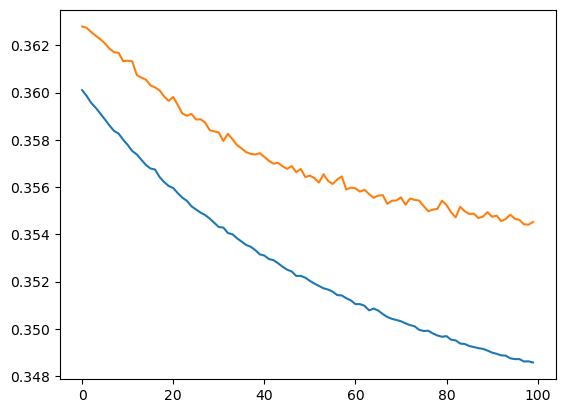

In [88]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])